Extracting deep features...


1500it [01:53, 13.27it/s]


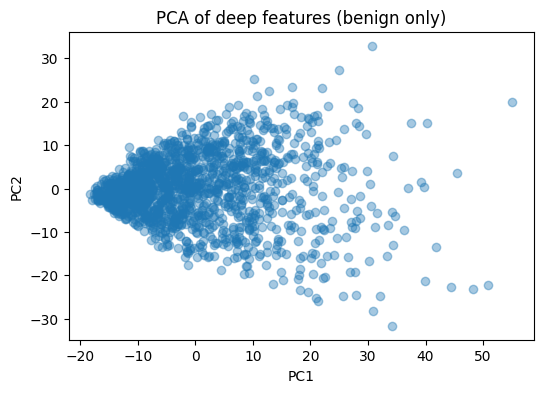

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import torch
import torchvision.models as models
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from pathlib import Path

# paths
path = Path().resolve().parent
bad_full = path / "samples" / "malignant"
good_full = path / "samples" / "benign"

source_dir = good_full  # using benign only for data explorations

# model setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
model.fc = torch.nn.Identity()  # remove classification layer
model = model.to(device)
model.eval()

transform = models.ResNet50_Weights.DEFAULT.transforms() 
# use ResNet50's default preprocessing (resize, normalize) 

# extract embeddings
embeddings = []

print("Extracting deep features...")
for img_path in tqdm(source_dir.iterdir()):
    img = Image.open(img_path).convert("RGB")
    x = transform(img).unsqueeze(0).to(device) # set batch size to 1

    with torch.no_grad():
        emb = model(x).cpu().numpy().flatten()

    embeddings.append(emb)

X = np.array(embeddings)

# normalize
X_norm = StandardScaler().fit_transform(X)

# PCA for visualization
X_2d = PCA(n_components=2).fit_transform(X_norm)

# plot raw distribution
plt.figure(figsize=(6,4))
plt.scatter(X_2d[:,0], X_2d[:,1], alpha=0.4)
plt.title("PCA of deep features (benign only)")
plt.xlabel("PC1"); plt.ylabel("PC2")

out_dir = path / "out"
out_dir.mkdir(exist_ok=True)

plt.savefig(out_dir / "pca_benign.png", dpi=300)
plt.show()